Dropping: ['Timestamp', 'Source IP Address', 'Destination IP Address', 'Source Port', 'Destination Port', 'Packet Length', 'Payload Data', 'Anomaly Scores', 'User Information', 'Device Information', 'Geo-location Data']
                             Feature  Importance
5   Attack Signature_Known Pattern B    0.104794
2                   Packet Type_Data    0.104124
12                 Log Source_Server    0.091690
11         Network Segment_Segment C    0.077092
1                       Protocol_UDP    0.075839
4                  Traffic Type_HTTP    0.073631
8                 Severity Level_Low    0.073198
6               Action Taken_Ignored    0.071442
3                   Traffic Type_FTP    0.069492
0                       Protocol_TCP    0.068758


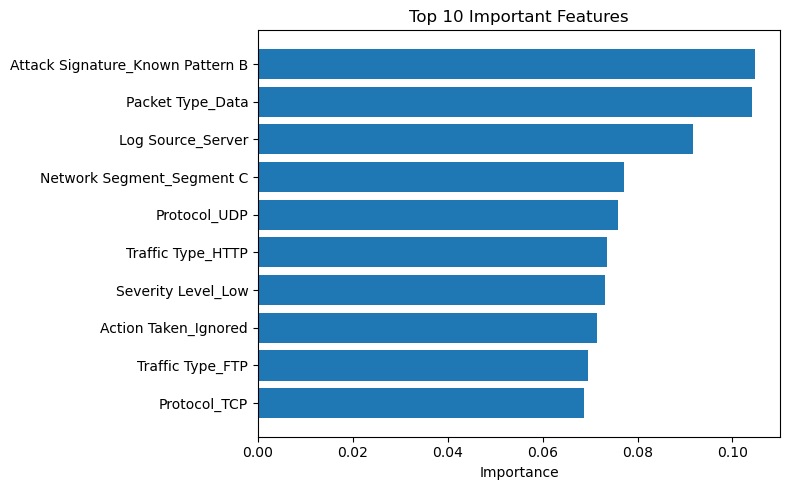

In [5]:

# RQ4: Feature Importance


import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# 1. LOAD DATA

df = pd.read_csv('D:/University Of Europe/ML/Assignment 1/Cyber Security Attacks Dataset.csv')


# 2. PREPROCESS (FIXED)

target = 'Attack Type'

df = df.dropna()

# 🔥 REMOVE HIGH CARDINALITY COLUMNS
threshold = 50

high_card_cols = [col for col in df.columns if df[col].nunique() > threshold]

print("Dropping:", high_card_cols)

df = df.drop(columns=high_card_cols)

# Separate
X = df.drop(columns=[target])
y = df[target]

# Encode ONLY small categorical columns
cat_cols = X.select_dtypes(include='object').columns

X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

# 3. SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4. TRAIN MODEL

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# 5. FEATURE IMPORTANCE

importances = model.feature_importances_

feat_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(feat_df.head(10))

# Save table
feat_df.to_csv("RQ4_feature_importance.csv", index=False)


# 6. PLOT

top_n = 10

plt.figure(figsize=(8,5))
plt.barh(feat_df["Feature"][:top_n], feat_df["Importance"][:top_n])
plt.gca().invert_yaxis()

plt.title("Top 10 Important Features")
plt.xlabel("Importance")

plt.tight_layout()
plt.savefig("RQ4_feature_importance.pdf")
plt.show()